# CERRA y CERRA-Land - series areales
***

***Autor:** Javier Díez Sierra*<br>
***Fecha:** 15-04-2026*<br>

**Introducción:**<br>
En este _notebook_ se calculan las series meteorológicas areales de las cuencas de BEAVERS-ES a partir de los datos meteorológicos de [CERRA](https://cds.climate.copernicus.eu/datasets/reanalysis-cerra-single-levels?tab=overview) para las variables temperatura y evapotraspiración potencial y de [CERRA-Land](https://cds.climate.copernicus.eu/datasets/reanalysis-cerra-land?tab=download) que han sido descargados del CDS de Copernicus. A diferencia de CERRA, CERRA-Land incluye un modelo de precipitación que asimila datos observacionales y que proporciona mejores resultados. 

Las series de CERRA y CERRA-Land comienzan en 1 de enero de 1984 y terminan el 31 de diciembre de 2025 (aunque hemos descargado hasta el 2022 para alinearlo con la base de datos de ROCIO-IBEB). Ya que las series de aforos comienzan el 1 de enero de 1979, usaremos dicho periodo como fecha inicial.

In [12]:
import os
import xarray as xr
import numpy as np
import xclim
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from xclim.core.units import convert_units_to

In [13]:
from ocab.config import Config
from ocab.basins.stats import read_data, read_pixarea, basin_statistics

# load configuration file
cfg = Config('config_BEAVERS_v100.yml')

# load basins shapefile
file = '../../docs/layers/reservoirs_basins_3sec.parquet'
basins = gpd.read_parquet(file)

# load pixel area to weigh the statistics
#pixarea = read_pixarea(cfg.path_efas / 'maps' / 'pixarea_iberian_01min.nc')
#pixarea = pixarea.rio.write_crs(cfg.crs)

In [14]:
def traverseDir(root, end):
    for (dirpath, dirnames, filenames) in os.walk(root):
        for file in filenames:
            if file.endswith((end)):
                yield os.path.join(dirpath, file)

In [15]:
root_cerra_land = '/lustre/gmeteo/WORK/PROYECTOS/2026_CAMELS-ES/cerra-land-spain-int/day/pr/'
root_cerra = '/lustre/gmeteo/WORK/PROYECTOS/2026_CAMELS-ES/cerra-spain-int/3-hour/tas/'

In [16]:
# load meteorological data
data_pr = xr.open_mfdataset(np.sort(list(traverseDir(f"{root_cerra_land}", ".nc"))), 
                            concat_dim="valid_time", combine="nested").unify_chunks()
data_tas_3_hour = xr.open_mfdataset(np.sort(list(traverseDir(f"{root_cerra}", ".nc"))), 
                            concat_dim="valid_time", combine="nested").unify_chunks()

In [17]:
# standarize
data_pr = data_pr.rename({"valid_time": "time"})
data_pr["tp"].attrs["units"] = "mm/d"
data_pr = data_pr.assign_coords(time=data_pr.time - np.timedelta64(6, "h"))

data_tas_3_hour = data_tas_3_hour.rename({"valid_time": "time"})
data_tas_3_hour["t2m"] = data_tas_3_hour["t2m"] - 273.15
data_tas_3_hour["t2m"].attrs["units"] = "C"
data_tas_3_hour['lat'].attrs["units"] = "degrees_north"
data_tas_3_hour['lon'].attrs["units"] = "degrees_east"

In [18]:
# calculate daily mean tas, daily maximum tas and daily minimum tas
data_tas = data_tas_3_hour.resample(time="1D").mean().compute()
data_tasmax = data_tas_3_hour.resample(time="1D").max().compute()
data_tasmin = data_tas_3_hour.resample(time="1D").min().compute()

In [19]:
# Calculate Potential Evapotranspiration using Hargreaves et al. (1985, 1994); https://doi.org/10.13031/2013.26773)
data_pet = xclim.indices.potential_evapotranspiration(tas = data_tas['t2m'],
                                                      tasmin=data_tasmin['t2m'], 
                                                      tasmax=data_tasmax['t2m'],
                                                      lat=data_tas.lat,
                                                      method='HG85').compute()
data_pet = (data_pet*86400).to_dataset(name = 'e0')
data_pet['e0'].attrs['units'] = 'mm/d'

In [20]:
# rename mean teamperatura and precipitation
data_pr = data_pr.rename_vars({'tp':'pr'})
data_tas = data_tas.rename_vars({'t2m':'ta'})

In [21]:
data = xr.merge([data_pr, data_tas, data_pet], join="inner")

In [22]:
data = data.drop_vars("expver")

In [23]:
# new time
new_time = pd.date_range(
    start="1979-01-01",
    end="2021-12-31",
    freq="D"
)

# reindex
data = data.reindex(time=new_time)

In [24]:
data = data.rio.write_crs(cfg.crs)
print(f"{data.nbytes / 1e9:.2f} GB")

0.60 GB


In [27]:
# compute statistics
results = basin_statistics(
    data=data[['ta', 'e0', 'pr']],
    basins=basins,
    statistic='mean',
    weight=None,
    decimals=1,
    overwrite=True,
    output=cfg.path_dataset / 'preprocessing' / 'catchstats' / 'meteo'/ 'CERRA' 
)

basins:   0%|          | 0/336 [00:00<?, ?it/s]

In [28]:
def plot_mean_maps(
    geo_df,
    parquet_files,
    start_period=None,
    end_period=None,
    months=None
):
    """
    geo_df: GeoDataFrame with columns ['ID', 'geometry', ...]
    parquet_files: dict {id: path_parquet}
    
    start_period: str or datetime (e.g. "2000-01-01")
    end_period: str or datetime (e.g. "2010-12-31")
    months: list of months (e.g. [6, 7, 8] for summer)
    """

    # --- 1. load and concatenate time series ---
    dfs = []
    for id_, path in parquet_files.items():
        df = pd.read_parquet(path, engine="pyarrow")
        
        df = df.reset_index()

        # Ensure time column exists (adjust name if needed)
        if "time" not in df.columns:
            raise ValueError("Expected a 'time' column in the data")

        df["time"] = pd.to_datetime(df["time"])

        # --- TIME FILTERS ---
        if start_period is not None:
            df = df[df["time"] >= pd.to_datetime(start_period)]

        if end_period is not None:
            df = df[df["time"] <= pd.to_datetime(end_period)]

        if months is not None:
            df = df[df["time"].dt.month.isin(months)]

        df["id"] = df["id"].astype(int)
        dfs.append(df)

    data = pd.concat(dfs)

    # --- 2. compute mean values per basin ---
    means = (
        data.groupby("id")[["ta_mean", "e0_mean", "pr_mean"]]
        .mean()
        .reset_index()
    )

    # --- 3. merge with spatial data ---
    gdf = geo_df.copy()
    gdf = gdf.merge(means, left_on="ID", right_on="id", how="left")

    # --- 4. plot maps ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    variables = ["ta_mean", "e0_mean", "pr_mean"]
    titles = ["Mean Temperature", "Mean E0", "Mean Precipitation"]

    for ax, var, title in zip(axes, variables, titles):
        gdf.plot(column=var, ax=ax, legend=True, cmap="viridis")
        ax.set_title(title)
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()

In [29]:
parquet_files = {
    int(p.stem): str(p)
    for p in (cfg.path_dataset / 'preprocessing' / 'catchstats' / 'meteo' / 'CERRA').glob("*.parquet")
}

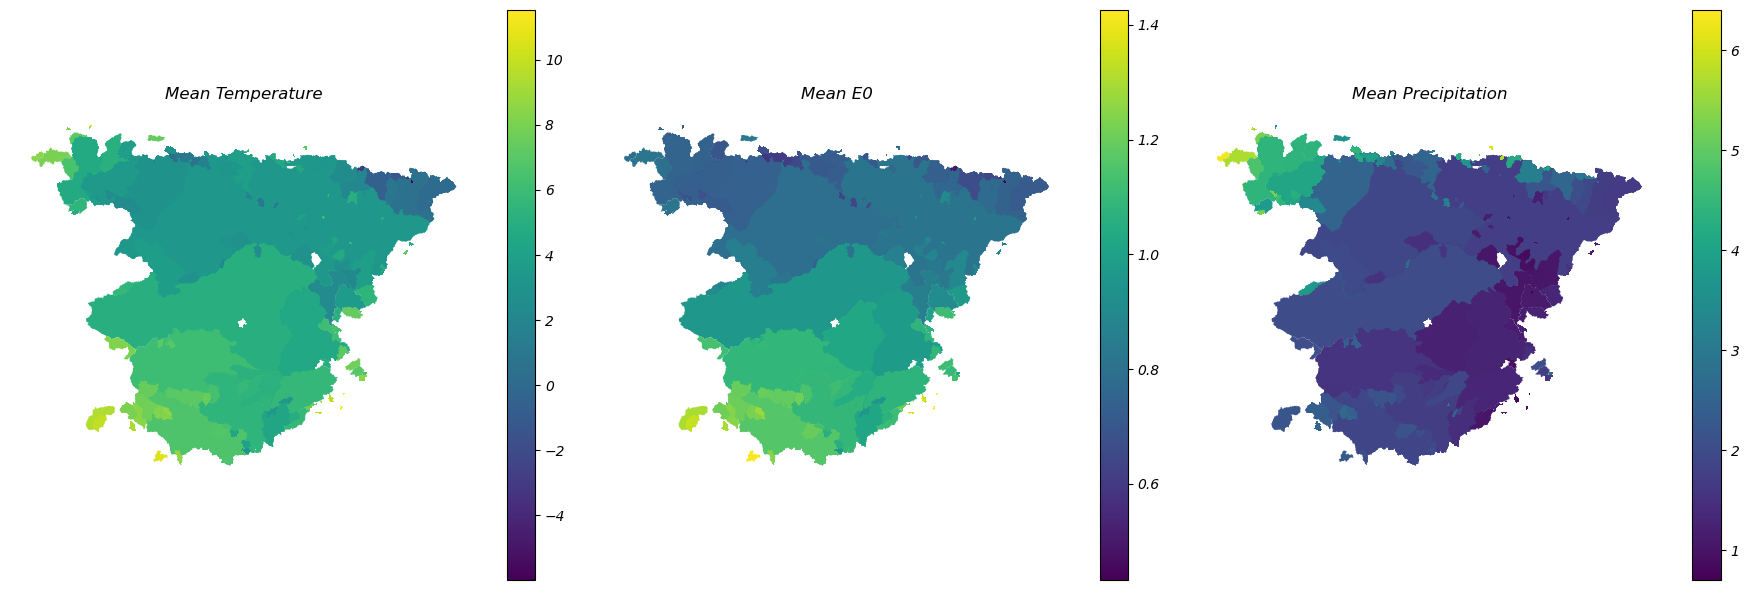

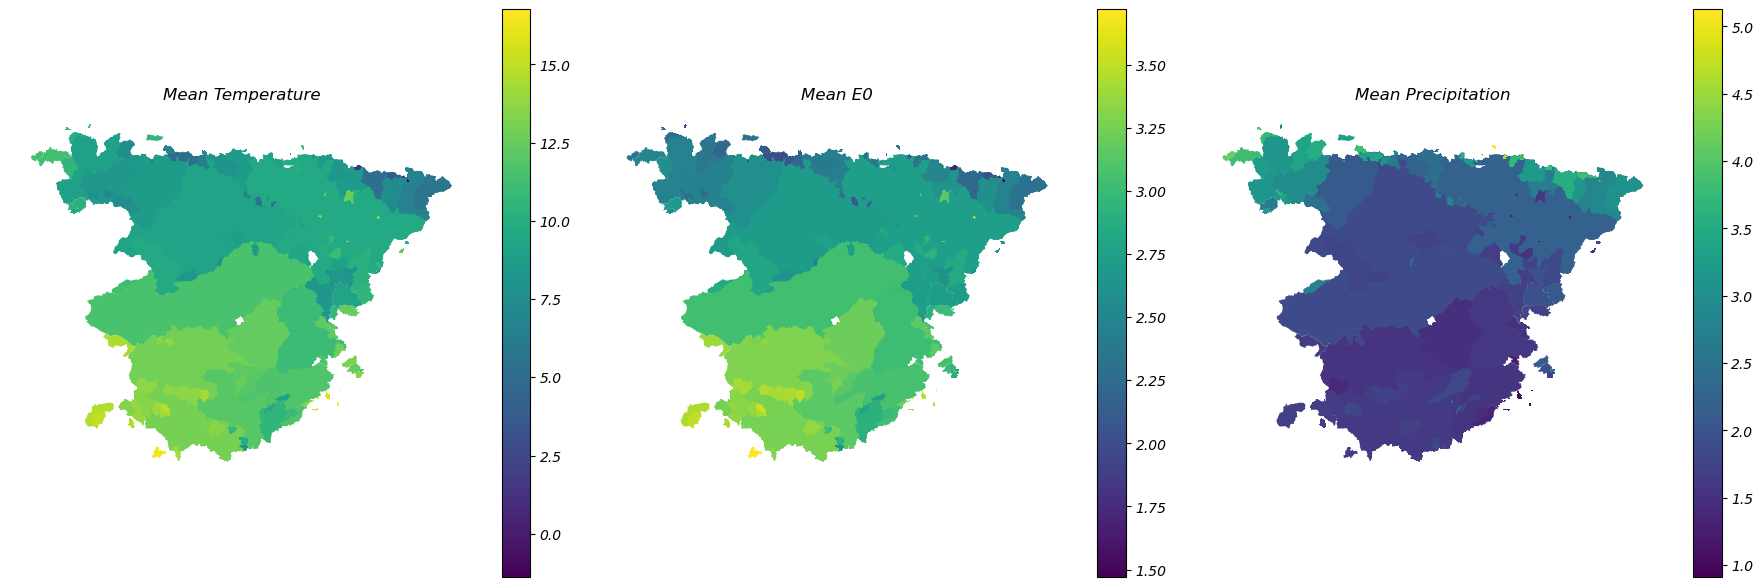

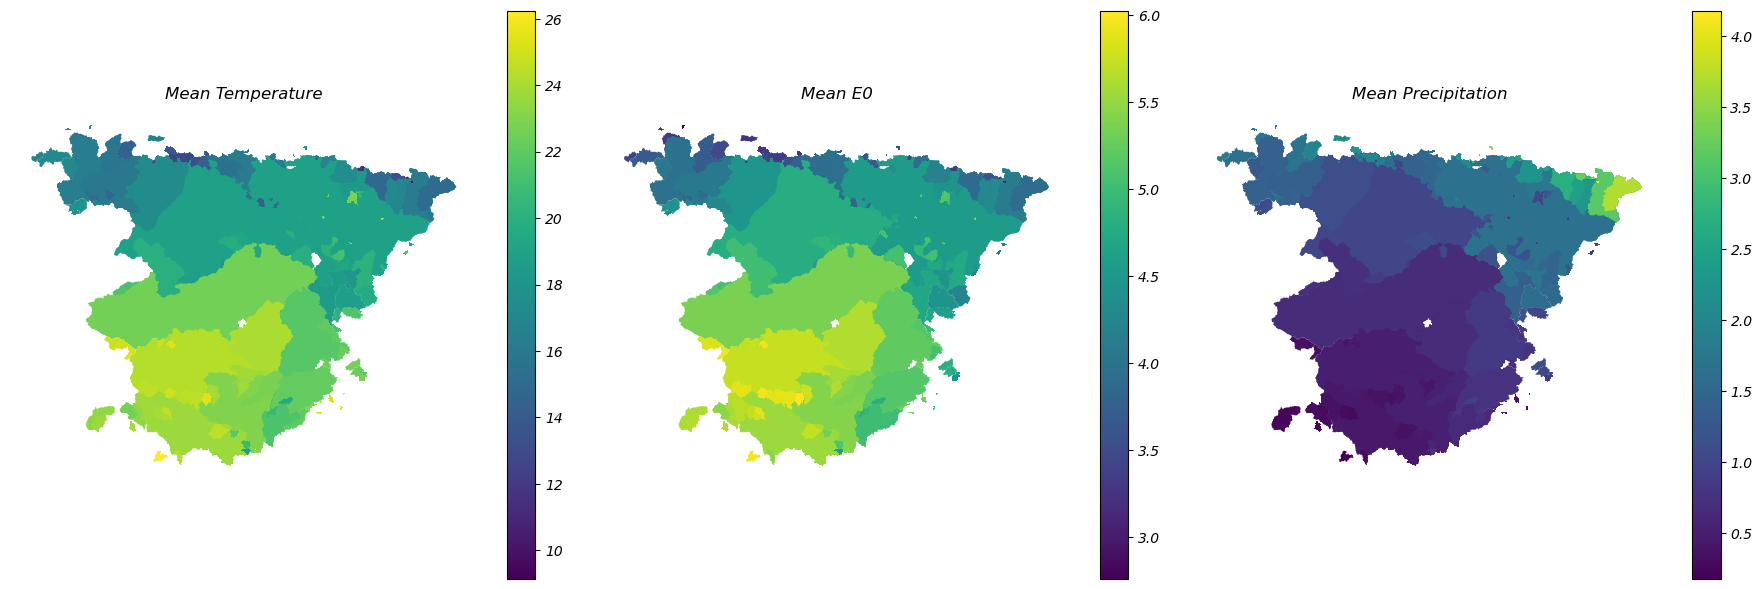

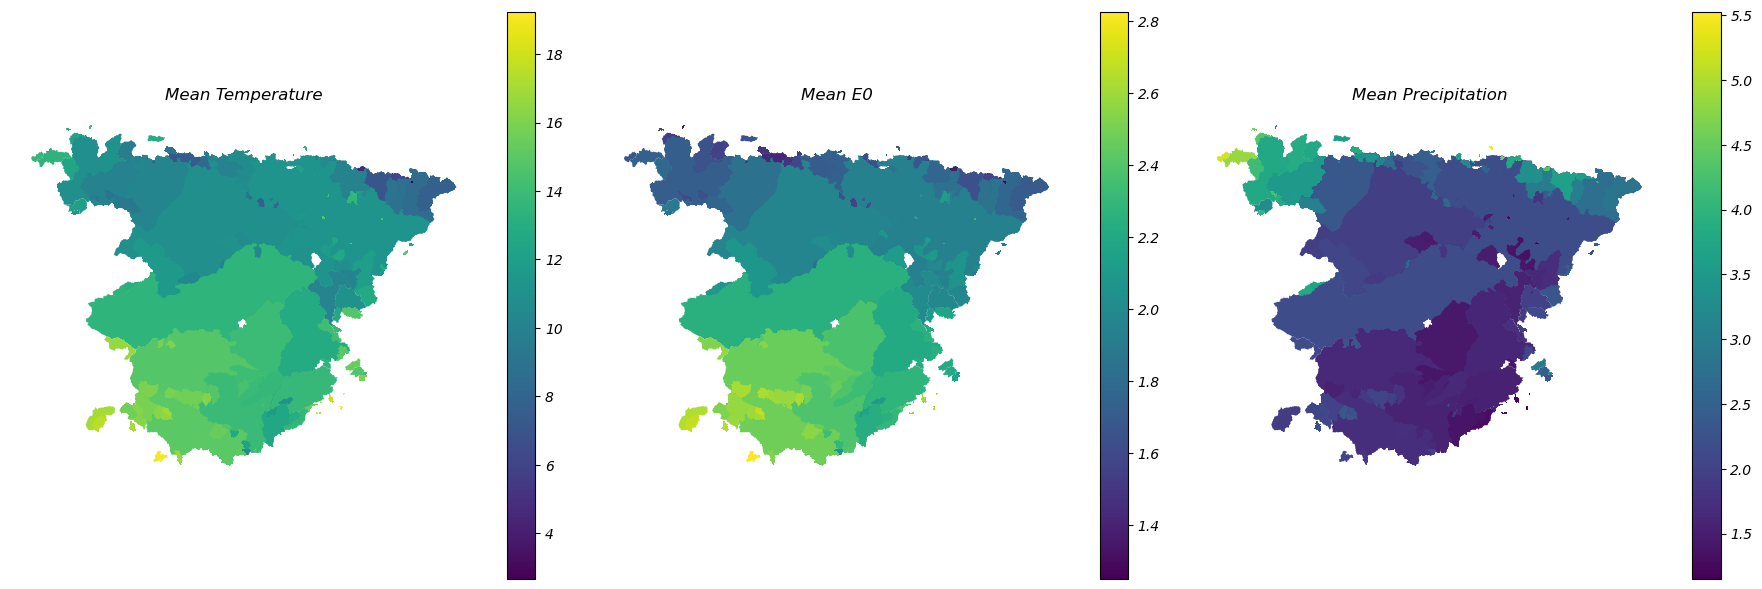

In [30]:
for season in [[12, 1, 2], [3, 4, 5], [6, 7, 8], [9, 10, 11]]:
    plot_mean_maps(basins, 
                   parquet_files, 
                   start_period="1979-01-01", end_period="2021-12-31", 
                   months=season)